# DC-DC converter

Set up the model of a DC-DC converter using Python. This model will simulate the behavior of a buck converter, which steps down voltage from a higher level to a lower level.

**Scope of this notebook:**
- Buck topology, **Continuous Conduction Mode (CCM) only** (DCM is deferred / not modeled).
- Ideal switch and diode.
- Ideal input voltage source (no series impedance); the input capacitor absorbs the AC/pulsating current so we can still estimate **input voltage ripple**.
- Both a hard-switching time-domain simulation and quick analytic ripple formulas are shown, so they can be cross-checked against each other.


In [6]:
# Load the reusable converter model.
# Note: the module file is `dc_dc_model.py` (hyphen in the name), so it can't
# be imported with a plain `import` statement - load it via importlib instead.

from models import dc_dc_model
import pathlib

import numpy as np
import matplotlib.pyplot as plt




## 1. Converter parameters

Define the buck converter's electrical parameters. The duty cycle is computed from the ideal CCM relationship `D = Vout / Vin`.


In [25]:
params = dc_dc_model.BuckConverterParams(
    Vin=12.0,       # ideal source voltage [V]
    Vout=3.3,       # target output voltage [V]
    L=1.5e-6,       # inductor [H]
    C_out=22e-6,   # output capacitor [F]
    C_in=10e-6,     # input capacitor [F]
    R_load=1,     # load resistance [ohm] -> Iout_avg = Vout / R_load = 2 A
    f_sw=1e6,     # switching frequency [Hz]
)

D = params.D
print(f"Duty cycle D = {D:.4f}")
print(f"Switching period T_sw = {params.T_sw*1e6:.3f} us")


Duty cycle D = 0.2750
Switching period T_sw = 1.000 us


## 2. Steady-state operating point & analytic ripple estimates

Compute the nominal average currents plus the standard analytic peak-to-peak ripple formulas for inductor current, output voltage, and input capacitor voltage.


In [26]:
ss = dc_dc_model.steady_state(params)
for k, v in ss.items():
    print(f"{k:12s} = {v:.6g}")


D            = 0.275
Iout_avg     = 3.3
IL_avg       = 3.3
Iin_avg      = 0.9075
dIL_pp       = 1.595
dVout_pp     = 0.0090625
dVin_pp      = 0.0657937


## 3. Open-loop switching (time-domain) simulation

Simulate the hard-switching model (ideal PWM) over many switching periods using `scipy.integrate.solve_ivp`, then look at the steady-state (last few periods) waveforms.


In [27]:
t, iL, vOut, vIn_cap, D_used = dc_dc_model.simulate_switching(
    params, n_periods=60, points_per_period=300
)

is_ccm = dc_dc_model.check_ccm(iL)
print(f"Duty cycle used: {D_used:.4f}")
print(f"Remained in CCM over steady-state tail: {is_ccm}")
if not is_ccm:
    print("WARNING: inductor current touched/crossed zero -> converter would "
          "enter DCM, which this model does not simulate. Increase L, "
          "increase f_sw, or increase load current to stay in CCM.")


Duty cycle used: 0.2750
Remained in CCM over steady-state tail: True


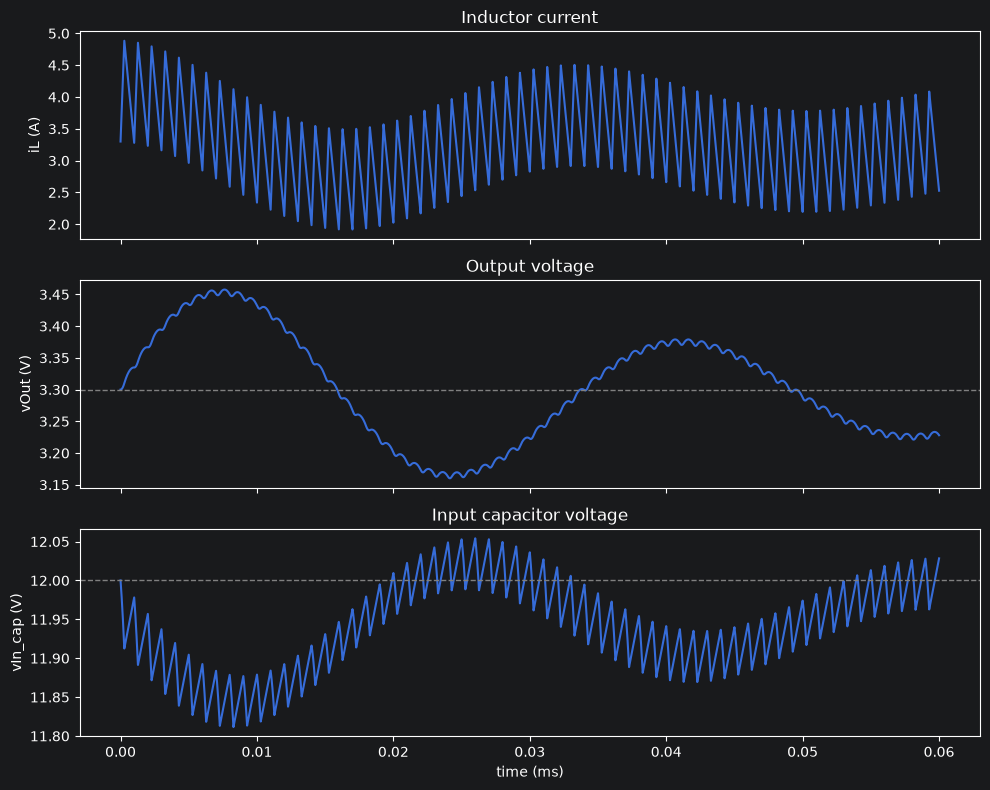

In [28]:
# Plot full simulation
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t * 1e3, iL)
axes[0].set_ylabel("iL (A)")
axes[0].set_title("Inductor current")

axes[1].plot(t * 1e3, vOut)
axes[1].axhline(params.Vout, color="gray", linestyle="--", linewidth=1)
axes[1].set_ylabel("vOut (V)")
axes[1].set_title("Output voltage")

axes[2].plot(t * 1e3, vIn_cap)
axes[2].axhline(params.Vin, color="gray", linestyle="--", linewidth=1)
axes[2].set_ylabel("vIn_cap (V)")
axes[2].set_xlabel("time (ms)")
axes[2].set_title("Input capacitor voltage")

plt.tight_layout()
plt.show()


### Zoomed-in steady-state ripple (last few switching periods)


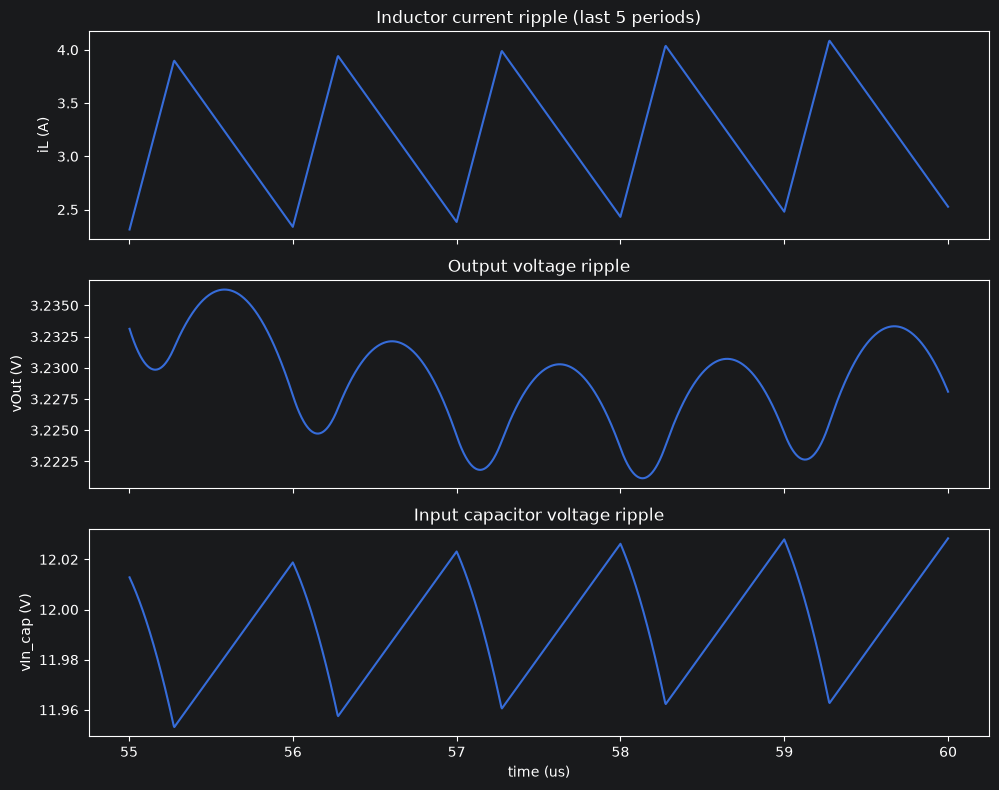

In [29]:
n_show = 5
t_window = n_show * params.T_sw
mask = t >= (t[-1] - t_window)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t[mask] * 1e6, iL[mask])
axes[0].set_ylabel("iL (A)")
axes[0].set_title(f"Inductor current ripple (last {n_show} periods)")

axes[1].plot(t[mask] * 1e6, vOut[mask])
axes[1].set_ylabel("vOut (V)")
axes[1].set_title("Output voltage ripple")

axes[2].plot(t[mask] * 1e6, vIn_cap[mask])
axes[2].set_ylabel("vIn_cap (V)")
axes[2].set_xlabel("time (us)")
axes[2].set_title("Input capacitor voltage ripple")

plt.tight_layout()
plt.show()


### Simulated vs. analytic ripple comparison


In [30]:
# Use the steady-state tail (last 30%) to measure simulated pk-pk ripple.
tail_start = int(len(t) * 0.7)

sim_dIL = iL[tail_start:].max() - iL[tail_start:].min()
sim_dVout = vOut[tail_start:].max() - vOut[tail_start:].min()
sim_dVin = vIn_cap[tail_start:].max() - vIn_cap[tail_start:].min()

print(f"{'Quantity':20s} {'Simulated':>12s} {'Analytic':>12s}")
print(f"{'Inductor ΔIL (A)':20s} {sim_dIL:12.4f} {ss['dIL_pp']:12.4f}")
print(f"{'Output ΔVout (V)':20s} {sim_dVout:12.4f} {ss['dVout_pp']:12.4f}")
print(f"{'Input ΔVin (V)':20s} {sim_dVin:12.4f} {ss['dVin_pp']:12.4f}")


Quantity                Simulated     Analytic
Inductor ΔIL (A)           1.8940       1.5950
Output ΔVout (V)           0.1550       0.0091
Input ΔVin (V)             0.1590       0.0658


## 4. (Optional) Duty-cycle-averaged model

A quick ripple-free averaged simulation, useful for checking the settling behavior / DC operating point without the switching-frequency detail.


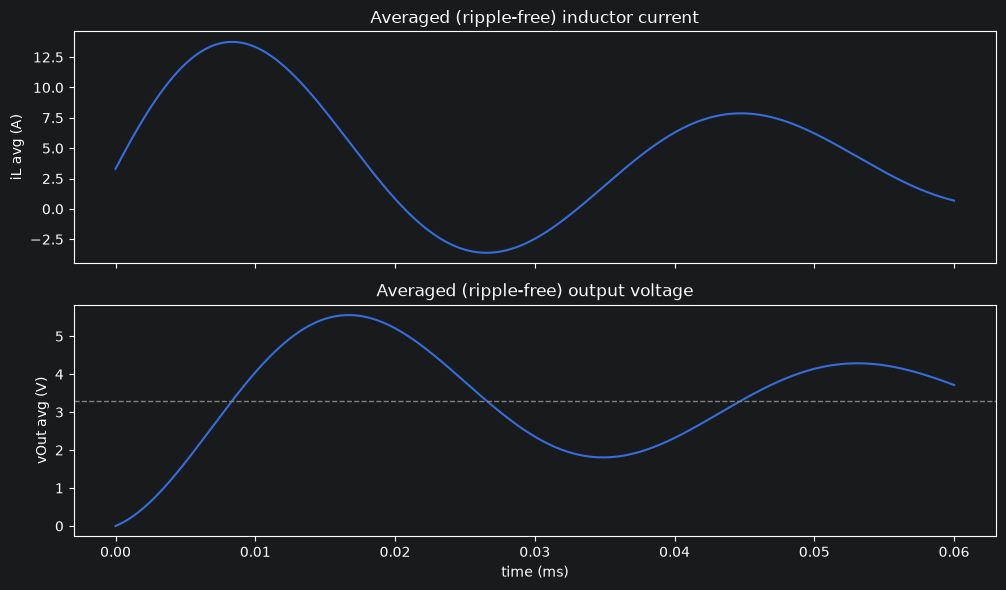

In [31]:
t_avg, iL_avg, vOut_avg, _ = dc_dc_model.simulate_averaged(params, n_periods=60)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_avg * 1e3, iL_avg)
axes[0].set_ylabel("iL avg (A)")
axes[0].set_title("Averaged (ripple-free) inductor current")

axes[1].plot(t_avg * 1e3, vOut_avg)
axes[1].axhline(params.Vout, color="gray", linestyle="--", linewidth=1)
axes[1].set_ylabel("vOut avg (V)")
axes[1].set_xlabel("time (ms)")
axes[1].set_title("Averaged (ripple-free) output voltage")

plt.tight_layout()
plt.show()


## 5. (Optional) Closed-loop PI regulation under a load step

Demonstrates a simple discrete PI controller regulating `Vout` by adjusting duty cycle once per switching period. Run with a nominal load, then verify behavior if you change `R_load` mid-notebook and re-run.


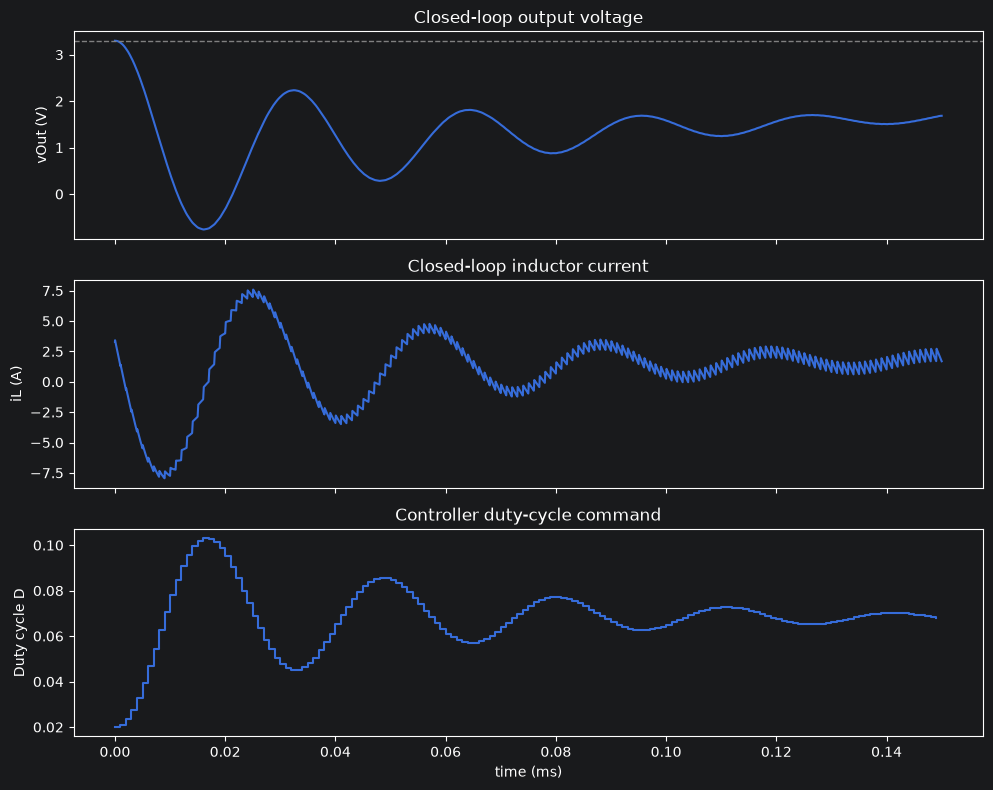

Final Vout: 1.6851 V (target 3.3 V)
Remained in CCM: True


In [32]:
controller = dc_dc_model.PIController(kp=0.02, ki=50.0)

t_cl, iL_cl, vOut_cl, vIn_cl, D_hist = dc_dc_model.simulate_switching_closed_loop(
    params, controller, vout_ref=params.Vout, n_periods=150, points_per_period=100
)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t_cl * 1e3, vOut_cl)
axes[0].axhline(params.Vout, color="gray", linestyle="--", linewidth=1)
axes[0].set_ylabel("vOut (V)")
axes[0].set_title("Closed-loop output voltage")

axes[1].plot(t_cl * 1e3, iL_cl)
axes[1].set_ylabel("iL (A)")
axes[1].set_title("Closed-loop inductor current")

period_times = np.arange(len(D_hist)) * params.T_sw
axes[2].step(period_times * 1e3, D_hist, where="post")
axes[2].set_ylabel("Duty cycle D")
axes[2].set_xlabel("time (ms)")
axes[2].set_title("Controller duty-cycle command")

plt.tight_layout()
plt.show()

print(f"Final Vout: {vOut_cl[-1]:.4f} V (target {params.Vout} V)")
print(f"Remained in CCM: {dc_dc_model.check_ccm(iL_cl)}")
